# Análisis Exploratorio

## Carga de archivos

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_excel('Datos.xlsx', sheet_name='Datos')
df.to_csv('Datos.csv', index=False, encoding='utf-8-sig')

In [16]:
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 161,036  |  Columnas: 13


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [17]:
df.dtypes

Año                        int64
Mes cod                    int64
Mes                       object
Vía                       object
Frontera                  object
País                      object
Región                    object
Región dos                object
Regiones OMT              object
MCEO                      object
Agrupación Residencia     object
Tipo de Viajero           object
Viajero                  float64
dtype: object

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Año,161036.0,NaN,NaN,NaN,2016.017543,4.552887,2009.0,2012.0,2016.0,2019.0,2026.0
Mes cod,161036.0,NaN,NaN,NaN,6.416075,3.531936,1.0,3.0,6.0,10.0,12.0
Mes,161036,12,Ene,14726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vía,161036,3,Terrestre,125873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frontera,161036,22,01 La Aurora,21424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,161036,235,Guatemala,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región,161036,17,EUROPA,32331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región dos,161036,11,Europa,54640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiones OMT,161036,26,AMÉRICA CENTRAL,31362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCEO,161036,8,08 OTROS,73173,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Construcción de la variable fecha

Se combina Año y Mes cod en una columna Fecha para poder analizar el comportamiento temporal y hacer la partición train/test de forma cronológica.

In [19]:
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
print("Rango de fechas:", df['Fecha'].min().strftime('%Y-%m'), "a", df['Fecha'].max().strftime('%Y-%m'))
print("Meses cubiertos:", df['Fecha'].nunique())

Rango de fechas: 2009-01 a 2026-06
Meses cubiertos: 210


## Comportamiento temporal del número de viajeros

Se agrega el total mensual de viajeros. Se grafican dos series: el total de la columna Viajero tal cual, y la suma Turista + Excursionista, comparación recomendada para evitar el quiebre metodológico de 2022–2023.

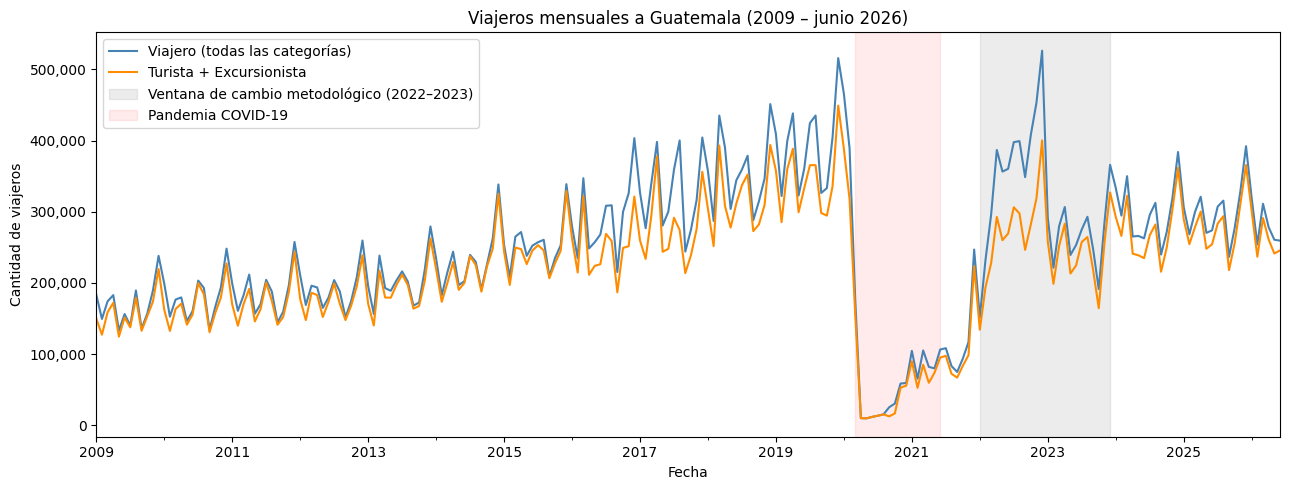

In [20]:
mensual_total = df.groupby('Fecha')['Viajero'].sum()

es_turista_exc = df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
mensual_turista_exc = df[es_turista_exc].groupby('Fecha')['Viajero'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
mensual_total.plot(ax=ax, label='Viajero (todas las categorías)', color='steelblue')
mensual_turista_exc.plot(ax=ax, label='Turista + Excursionista', color='darkorange')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-12-31'), color='gray', alpha=0.15,
           label='Ventana de cambio metodológico (2022–2023)')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), color='red', alpha=0.08,
           label='Pandemia COVID-19')
ax.set_title('Viajeros mensuales a Guatemala (2009 – junio 2026)')
ax.set_ylabel('Cantidad de viajeros')
ax.set_xlabel('Fecha')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

La serie Viajero (todas las categorías) cae fuertemente a partir de 2023 porque deja de incluir viajeros no turísticos de alta frecuencia, esto no representa una caída real del turismo. La serie Turista + Excursionista es consistente en todo el período, muestra estacionalidad anual, la caída por la pandemia y una recuperación sostenida desde 2022 que actualmente supera los niveles pre-pandemia.

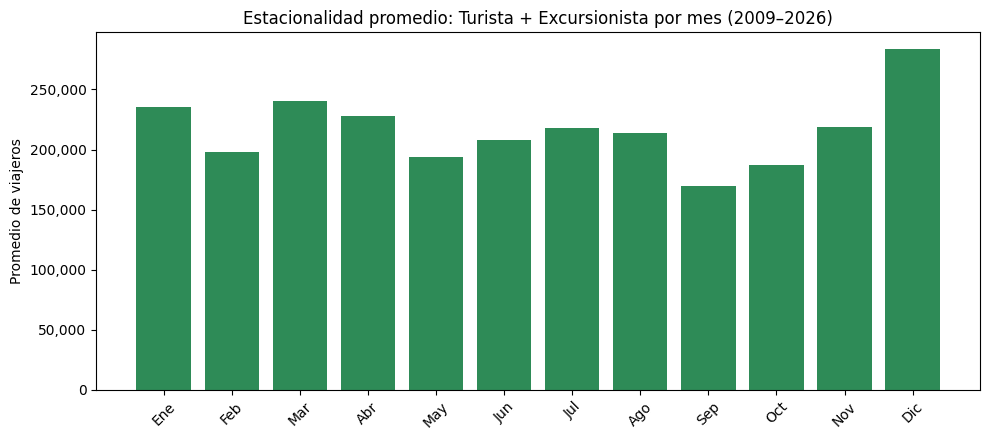

In [21]:
# Estacionalidad: promedio de viajeros (Turista+Excursionista) por mes del año
serie_te = df[es_turista_exc].copy()
prom_mes = serie_te.groupby('Mes cod')['Viajero'].sum().div(serie_te['Año'].nunique())
meses_nombre = serie_te.drop_duplicates('Mes cod').set_index('Mes cod')['Mes'].reindex(prom_mes.index)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(meses_nombre, prom_mes.values, color='seagreen')
ax.set_title('Estacionalidad promedio: Turista + Excursionista por mes (2009–2026)')
ax.set_ylabel('Promedio de viajeros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hay estacionalidad marcada, los meses de mitad y fin de año muestran mayor afluencia, consistente con vacaciones y temporada alta de turismo.

## Países con más viajeros

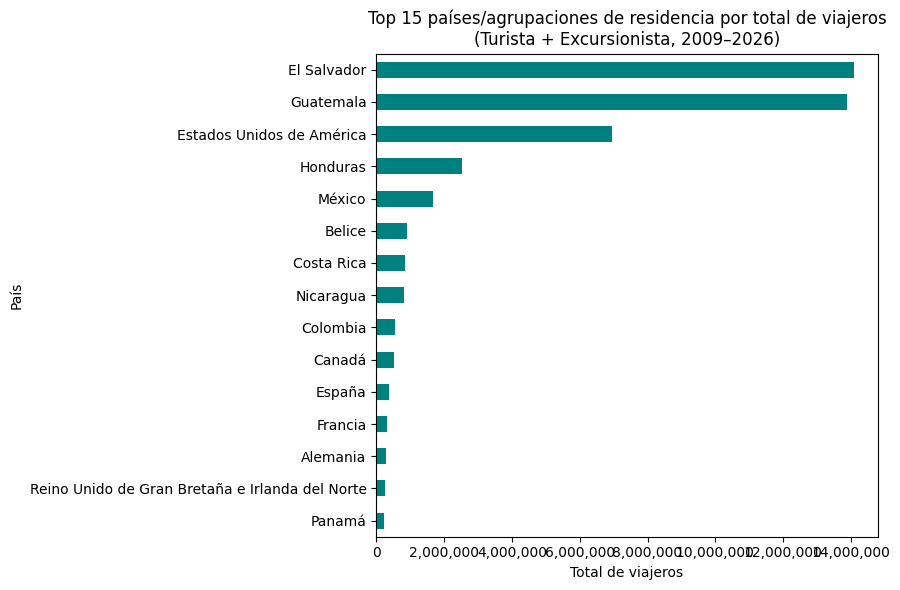

País
El Salvador                                        1.407914e+07
Guatemala                                          1.387039e+07
Estados Unidos de América                          6.965680e+06
Honduras                                           2.520974e+06
México                                             1.678423e+06
Belice                                             9.161011e+05
Costa Rica                                         8.602407e+05
Nicaragua                                          8.111454e+05
Colombia                                           5.494947e+05
Canadá                                             5.167079e+05
España                                             3.885718e+05
Francia                                            3.292003e+05
Alemania                                           2.907738e+05
Reino Unido de Gran Bretaña e Irlanda del Norte    2.595015e+05
Panamá                                             2.259434e+05
Name: Viajero, dtype: float64

In [22]:
top_paises = (df[es_turista_exc].groupby('País')['Viajero'].sum()
              .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top_paises.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 países/agrupaciones de residencia por total de viajeros\n(Turista + Excursionista, 2009–2026)')
ax.set_xlabel('Total de viajeros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

top_paises

El flujo de viajeros está dominado por países vecinos de Centroamérica y por Estados Unidos, lo cual es consistente con los patrones de turismo y comercio fronterizo de Guatemala. 

## Regiones con más viajeros

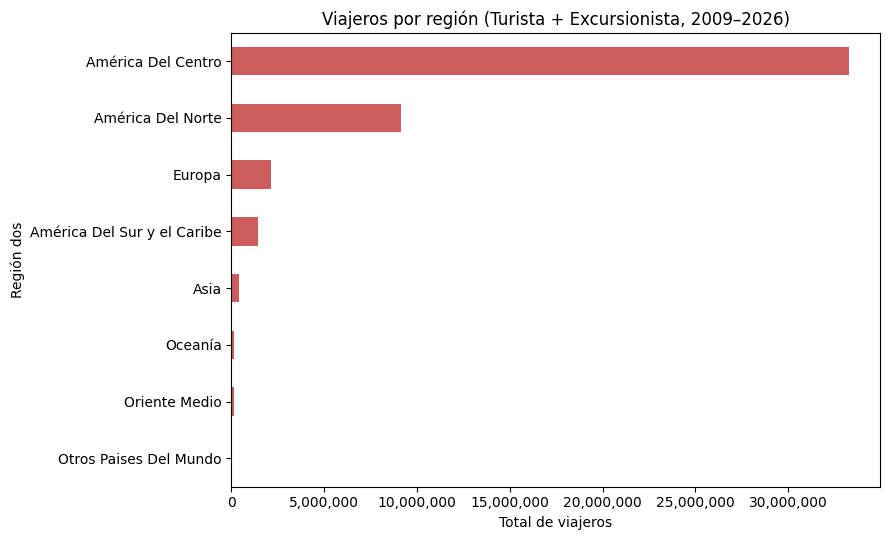

Región dos
América Del Centro             3.328393e+07
América Del Norte              9.160810e+06
Europa                         2.149271e+06
América Del Sur y el Caribe    1.413590e+06
Asia                           4.103335e+05
Oceanía                        1.355054e+05
Oriente Medio                  1.337352e+05
Otros Paises Del Mundo         2.391430e+04
Name: Viajero, dtype: float64

In [23]:
top_regiones = (df[es_turista_exc].groupby('Región dos')['Viajero'].sum()
                 .sort_values(ascending=False))
top_regiones = top_regiones[~top_regiones.index.isin(['0'])]  # excluye código inválido detectado en la sección 6

fig, ax = plt.subplots(figsize=(9, 5.5))
top_regiones.sort_values().plot(kind='barh', ax=ax, color='indianred')
ax.set_title('Viajeros por región (Turista + Excursionista, 2009–2026)')
ax.set_xlabel('Total de viajeros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

top_regiones

América Central y América del Norte concentran la gran mayoría de los viajeros, seguidas por Europa y el resto de regiones. Esto refuerza el patrón observado donde el turismo fronterizo regional domina.

## Vías de ingreso y fronteras más usadas

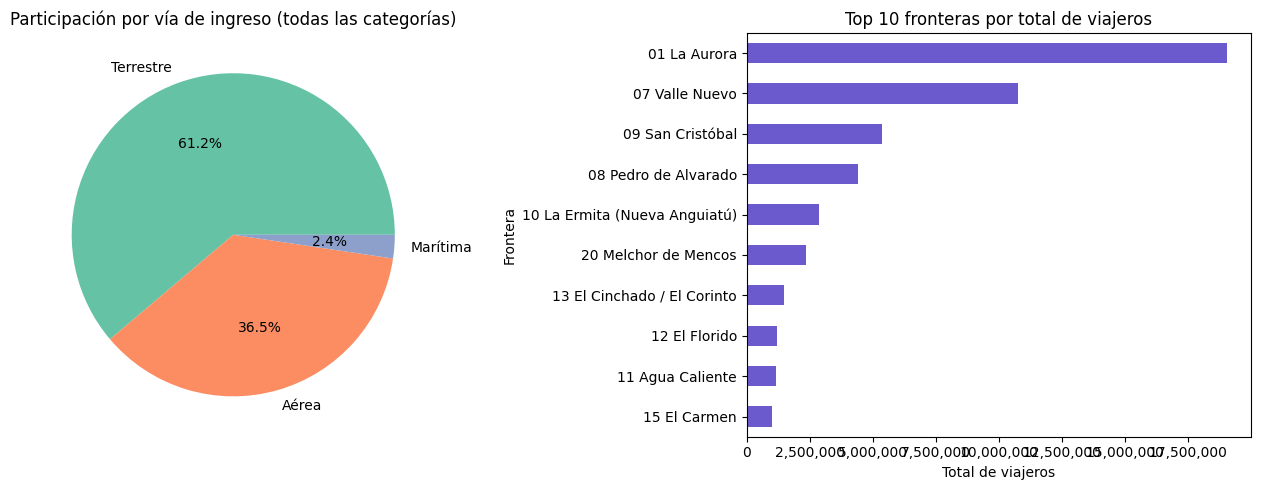

Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64


In [24]:
via = df.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(via.values, labels=via.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[0].set_title('Participación por vía de ingreso (todas las categorías)')

top_fronteras = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(10)
top_fronteras.sort_values().plot(kind='barh', ax=axes[1], color='slateblue')
axes[1].set_title('Top 10 fronteras por total de viajeros')
axes[1].set_xlabel('Total de viajeros')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print(via)

La vía aérea concentra la mayor proporción de viajeros a nivel agregado, pero al desagregar por frontera, varios pasos terrestres fronterizos con México, Honduras y El Salvador aparecen entre los de mayor volumen.

## Valores faltantes, atípicos y duplicados

### Valores faltantes

In [25]:
faltantes = df.isna().sum()
faltantes_pct = (faltantes / len(df) * 100).round(2)
pd.DataFrame({'faltantes': faltantes, '% faltante': faltantes_pct})

,faltantes,% faltante
Año,0,0.0
Mes cod,0,0.0
Mes,0,0.0
Vía,0,0.0
Frontera,0,0.0
País,0,0.0
Región,0,0.0
Región dos,0,0.0
Regiones OMT,0,0.0
MCEO,0,0.0


No hay valores nulos en ninguna columna. Sin embargo, existen códigos de "faltante" disfrazados de categoría válida: Región dos contiene el valor '0' y Regiones OMT contiene '0x2a' en vez de un nombre de región.

In [26]:
print("Filas con Región dos == '0':", (df['Región dos'] == '0').sum())
print("Filas con Regiones OMT == '0x2a':", (df['Regiones OMT'] == '0x2a').sum())

df[df['Región dos'] == '0'][['Año','Mes','País','Región','Tipo de Viajero','Viajero']].head()

Filas con Región dos == '0': 13
Filas con Regiones OMT == '0x2a': 5


,Año,Mes,País,Región,Tipo de Viajero,Viajero
136757,2022,Ene,Islas Vírgenes Americanas,OTROS CARIBEÑOS,Turista,43.0
137478,2022,Feb,Islas Vírgenes Americanas,OTROS CARIBEÑOS,Turista,48.0
137620,2022,Feb,República Democrática del Congo,OTROS PAISES DEL MUNDO,Excursionista,1.0
137621,2022,Feb,República Democrática del Congo,OTROS PAISES DEL MUNDO,Turista,1.0
138151,2022,Mar,Islas Vírgenes Americanas,OTROS CARIBEÑOS,Turista,53.0


In [ ]:
df[df['Región dos'] == '0']['Tipo de Viajero'].value_counts()

Tipo de Viajero
Turista          9
Excursionista    4
Name: count, dtype: int64

Estos códigos aparecen concentrados en el período 2022 y en su mayoría corresponden a la categoría Tipo de Viajero = Cruceristas o registros de transición donde la agrupación regional no se completó. Deben tratarse como faltantes categóricos y excluirse al analizar Región dos y Regiones OMT.

### Valores atípicos

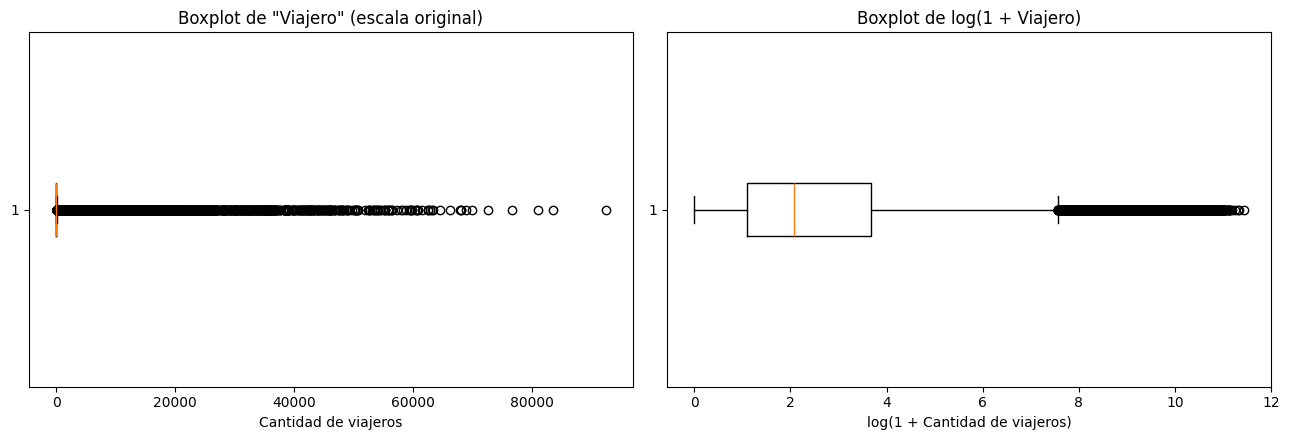

Q1=2.0  Q3=38.9  IQR=36.9  límite superior=94.2
Registros por encima del límite superior (regla IQR): 26,390 (16.4% del total)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].boxplot(df['Viajero'], vert=False)
axes[0].set_title('Boxplot de "Viajero" (escala original)')
axes[0].set_xlabel('Cantidad de viajeros')

axes[1].boxplot(np.log1p(df['Viajero']), vert=False)
axes[1].set_title('Boxplot de log(1 + Viajero)')
axes[1].set_xlabel('log(1 + Cantidad de viajeros)')

plt.tight_layout()
plt.show()

q1, q3 = df['Viajero'].quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
outliers = df[df['Viajero'] > lim_sup]
print(f"Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}  límite superior={lim_sup:.1f}")
print(f"Registros por encima del límite superior (regla IQR): {len(outliers):,} ({len(outliers)/len(df)*100:.1f}% del total)")

In [30]:
outliers.sort_values('Viajero', ascending=False)[['Año','Mes','Vía','Frontera','País','Tipo de Viajero','Viajero']].head(10)

,Año,Mes,Vía,Frontera,País,Tipo de Viajero,Viajero
98206,2017,Ago,Terrestre,20 Melchor de Mencos,Belice,Viajero,92336.035067
124846,2019,Dic,Aérea,01 La Aurora,Guatemala,Turista,83511.000000
113144,2018,Dic,Aérea,01 La Aurora,Guatemala,Turista,81030.061080
143464,2022,Dic,Aérea,01 La Aurora,Guatemala,Turista,76588.000000
101056,2017,Dic,Aérea,01 La Aurora,Guatemala,Turista,72545.000000
158357,2025,Dic,Terrestre,07 Valle Nuevo,El Salvador,Turista,69805.998425
123854,2019,Nov,Aérea,01 La Aurora,Guatemala,Turista,68877.000000
153238,2024,Dic,Terrestre,07 Valle Nuevo,El Salvador,Turista,68085.768243
158279,2025,Dic,Aérea,01 La Aurora,Estados Unidos de América,Turista,67952.000000
77012,2015,Dic,Aérea,01 La Aurora,Guatemala,Turista,67786.000000


La regla IQR marca como "atípico" un porcentaje importante de filas porque Viajero es una variable asimétrica, cada fila es un cruce de categorías, así que pocas combinaciones muy frecuentes concentran volúmenes enormes frente a la mayoría de combinaciones raras. No se recomienda eliminarlos, ya que representan la mayor parte del volumen real de viajeros.

### Valores duplicados

In [ ]:
dup_exactos = df.duplicated().sum()
print(f"Filas completamente duplicadas: {dup_exactos}")

claves = ['Año','Mes cod','Vía','Frontera','País','Región','Región dos','Regiones OMT','MCEO','Agrupación Residencia','Tipo de Viajero']
dup_clave = df.duplicated(subset=claves).sum()
print(f"Filas con la misma combinación de categorías repetida (posible doble conteo): {dup_clave}")

Filas completamente duplicadas: 0
Filas con la misma combinación de categorías repetida (posible doble conteo): 0


No hay filas completamente duplicadas. Si existieran duplicados por combinación de categorías, habría que sumarlos en vez de eliminarlos.

## Estadística descriptiva

In [31]:
df['Viajero'].describe()

count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

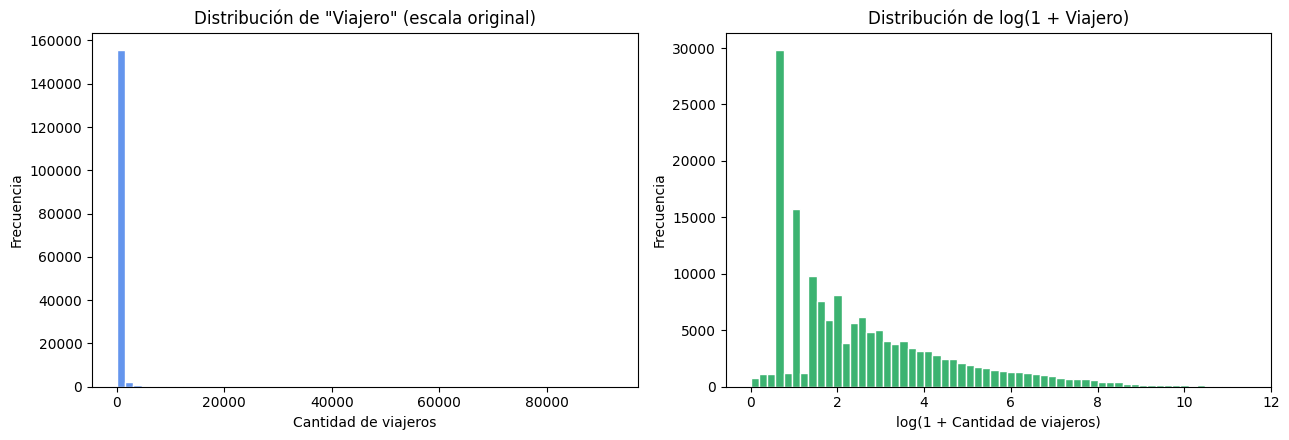

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['Viajero'], bins=60, color='cornflowerblue', edgecolor='white')
axes[0].set_title('Distribución de "Viajero" (escala original)')
axes[0].set_xlabel('Cantidad de viajeros')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['Viajero']), bins=60, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribución de log(1 + Viajero)')
axes[1].set_xlabel('log(1 + Cantidad de viajeros)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [33]:
print("Asimetría (skewness):", df['Viajero'].skew().round(2))
print("Curtosis:", df['Viajero'].kurt().round(2))

Asimetría (skewness): 15.44
Curtosis: 298.01


La distribución de Viajero está fuertemente sesgada a la derecha, lo cual es típico cuando hay muchas combinaciones categóricas. En escala logarítmica la distribución es mucho más simétrica y manejable, por esto una transformación log podría ser útil.

## División del conjunto de entrenamiento y prueba (70/30)

In [34]:
serie_mensual = mensual_turista_exc.sort_index()
n_meses = len(serie_mensual)
n_train = int(round(n_meses * 0.7))

fecha_corte = serie_mensual.index[n_train - 1]
print(f"Total de meses: {n_meses}")
print(f"Meses de entrenamiento: {n_train} ({n_train/n_meses*100:.1f}%)  ->  hasta {fecha_corte.strftime('%Y-%m')}")
print(f"Meses de prueba: {n_meses - n_train} ({(n_meses-n_train)/n_meses*100:.1f}%)  ->  desde {serie_mensual.index[n_train].strftime('%Y-%m')}")

Total de meses: 210
Meses de entrenamiento: 147 (70.0%)  ->  hasta 2021-03
Meses de prueba: 63 (30.0%)  ->  desde 2021-04


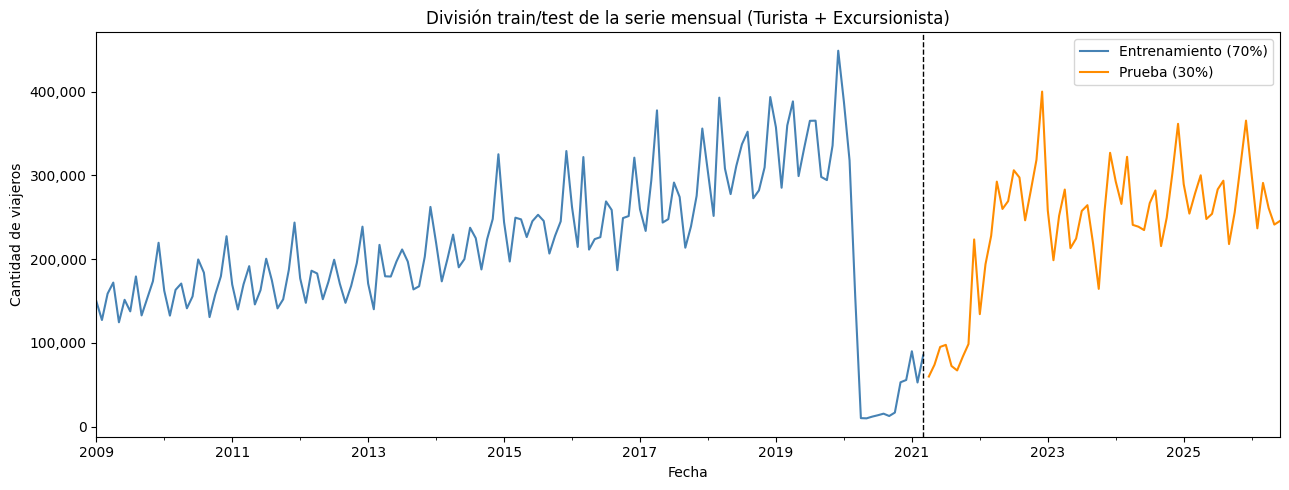

In [35]:
train_serie = serie_mensual.iloc[:n_train]
test_serie = serie_mensual.iloc[n_train:]

fig, ax = plt.subplots(figsize=(13, 5))
train_serie.plot(ax=ax, label='Entrenamiento (70%)', color='steelblue')
test_serie.plot(ax=ax, label='Prueba (30%)', color='darkorange')
ax.axvline(fecha_corte, color='black', linestyle='--', linewidth=1)
ax.set_title('División train/test de la serie mensual (Turista + Excursionista)')
ax.set_ylabel('Cantidad de viajeros')
ax.set_xlabel('Fecha')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [36]:
# Partición correspondiente sobre el dataset desagregado original (misma fecha de corte)
train_df = df[df['Fecha'] <= fecha_corte].copy()
test_df = df[df['Fecha'] > fecha_corte].copy()

print(f"Train: {train_df.shape[0]:,} filas ({train_df.shape[0]/len(df)*100:.1f}%)  |  {train_df['Fecha'].min().strftime('%Y-%m')} a {train_df['Fecha'].max().strftime('%Y-%m')}")
print(f"Test:  {test_df.shape[0]:,} filas ({test_df.shape[0]/len(df)*100:.1f}%)  |  {test_df['Fecha'].min().strftime('%Y-%m')} a {test_df['Fecha'].max().strftime('%Y-%m')}")

Train: 131,442 filas (81.6%)  |  2009-01 a 2021-03
Test:  29,594 filas (18.4%)  |  2021-04 a 2026-06


In [37]:
train_df.to_csv('train.csv', index=False, encoding='utf-8-sig')
test_df.to_csv('test.csv', index=False, encoding='utf-8-sig')
print("Guardados: train.csv y test.csv")

Guardados: train.csv y test.csv
